# Урок 1. Классификация текстов: сильный baseline на TF-IDF

🎯 **Цели урока**

- построить baseline для классификации тональности русских отзывов: TF-IDF + логистическая регрессия;
- сравнить слова, n-граммы и символьные n-граммы;
- заглянуть внутрь модели: какие слова она считает важными и почему ей нужен порядок слов;
- разобрать ошибки и понять, где потолок качества на этих данных.

📖 **Теория:** раздел «Как текст становился числами».

**Данные:** RuReviews (Apache 2.0) — 90 тысяч отзывов об одежде, 3 класса, уже поделены на train,
validation и test. С этими данными мы познакомились в M02; здесь используем их целиком.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline, make_union

from mlcourse import fetch

pd.set_option("display.max_colwidth", 140)
folder = fetch("rureviews")
train, val, test = (pd.read_json(folder / f"{s}.jsonl", lines=True) for s in ("train", "validation", "test"))
labels = ["negative", "neutral", "positive"]
print(len(train), len(val), len(test))
train.sample(4, random_state=3)[["label_text", "text"]]

45000 15000 15000


,label_text,text
10073,positive,"отличные джинсы,точный размер ,хорошее качесиво"
22743,negative,Отвратительная вещь из тонкой ткани. Просто тряпка для мытья полов. Не рекомендую
37481,positive,"Доставка быстрая, кофты хорошего качества, без затяжек и дырок.\n\nСпасибо!"
1657,positive,"все хорошо, и по размеру и по длинне"


In [2]:
words = train.text.str.split().str.len()
print(f"слов в отзыве: медиана {words.median():.0f}, 95-й перцентиль {words.quantile(0.95):.0f}")
print(train.label_text.value_counts().to_dict())

слов в отзыве: медиана 14, 95-й перцентиль 59
{'positive': 15000, 'neutral': 15000, 'negative': 15000}


Отзывы короткие — половина не длиннее 16 слов. Классы сбалансированы, поэтому baseline «всегда один
класс» даёт 33%, а accuracy — честная метрика.

## 1. TF-IDF + логистическая регрессия

In [3]:
def fit_and_score(vectorizer, C=1.0):
    start = time.perf_counter()
    model = make_pipeline(vectorizer, LogisticRegression(C=C, max_iter=3000)).fit(train.text, train.label_text)
    return model, accuracy_score(val.label_text, model.predict(val.text)), time.perf_counter() - start


model_words, acc, sec = fit_and_score(TfidfVectorizer(min_df=2))
print(f"слова: validation accuracy {acc:.4f}, обучение {sec:.0f} с, словарь {len(model_words[0].vocabulary_)}")
print(classification_report(val.label_text, model_words.predict(val.text), digits=3))

слова: validation accuracy 0.7325, обучение 8 с, словарь 17771


              precision    recall  f1-score   support

    negative      0.721     0.711     0.716      5000
     neutral      0.622     0.651     0.636      5000
    positive      0.863     0.836     0.849      5000

    accuracy                          0.732     15000
   macro avg      0.735     0.732     0.734     15000
weighted avg      0.735     0.732     0.734     15000



73% на трёх классах за пару секунд обучения. Хуже всего модель узнаёт `neutral`: нейтральный отзыв
состоит из тех же слов, что и хвалебный или ругательный, только в другой пропорции.

## 2. Слова, n-граммы, символы

Сравним на validation несколько представлений. Тест не трогаем до выбора лучшего.

In [4]:
variants = {
    "слова": TfidfVectorizer(min_df=2),
    "слова + биграммы": TfidfVectorizer(min_df=2, ngram_range=(1, 2)),
    "символы 2–5": TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, max_features=300_000),
    "слова + биграммы + символы": make_union(
        TfidfVectorizer(min_df=2, ngram_range=(1, 2)),
        TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, max_features=300_000),
    ),
}
results, models = {}, {}
for name, vec in variants.items():
    models[name], acc, sec = fit_and_score(vec)
    results[name] = {"validation accuracy": acc, "обучение, с": sec}
pd.DataFrame(results).T.round(4)

,validation accuracy,"обучение, с"
слова,0.7325,10.1929
слова + биграммы,0.7416,35.6590
символы 2–5,0.7417,94.9664
слова + биграммы + символы,0.7457,50.6025


Биграммы и символьные n-граммы добавляют по процентному пункту, их комбинация — ещё немного.
Символы ловят разные формы одного слова («маломерит», «маломерка», «маломерное») и опечатки.
Выигрыш небольшой: у задачи есть потолок, до которого мы ещё дойдём.

## 3. Что выучила модель

У логистической регрессии для каждого класса свой вектор весов. Посмотрим на самые сильные
признаки модели на словах и биграммах.

In [5]:
bigram_model = models["слова + биграммы"]
vocab = np.array(bigram_model[0].get_feature_names_out())
coef = bigram_model[-1].coef_  # [3 класса, число признаков]
for k, name in enumerate(bigram_model[-1].classes_):
    top = vocab[np.argsort(-coef[k])[:12]]
    print(f"{name:9} ← {', '.join(top)}")

negative  ← не, ужасное, ужасно, не рекомендую, спор, не вернули, не соответствует, не довольна, не советую, ужасная, продавец, ужас
neutral   ← звезды, не очень, три звезды, не соответствует, короткие, так себе, не, не понравилась, ну, слишком, синтетика, целом
positive  ← спасибо, супер, отлично, рекомендую, хорошая, отличная, довольна, хорошо, отличное, отличные, идеально, хорошее


Признаки осмысленные: благодарности и «рекомендую» — за positive, «не пришёл», «вернули деньги» — за
negative. Neutral держится на словах-смягчителях: «но», «немного», «в целом», «нормально».

### Порядок слов важен

Мешок слов не видит, к чему относится «не». Сравним модель на словах с моделью на биграммах.

In [6]:
probes = ["понравилось", "не понравилось", "качество хорошее", "качество не очень хорошее",
          "не пожалела о покупке", "пожалела о покупке"]
compare = pd.DataFrame({
    "слова": models["слова"].predict(probes),
    "слова + биграммы": bigram_model.predict(probes),
}, index=probes)
compare

,слова,слова + биграммы
понравилось,positive,positive
не понравилось,negative,negative
качество хорошее,positive,positive
качество не очень хорошее,positive,neutral
не пожалела о покупке,negative,negative
пожалела о покупке,positive,positive


«Не понравилось» обе модели понимают: слово «не» само по себе — сильный признак негатива (оно первое
в списке весов negative). Но из-за этого обе считают негативом похвалу «не пожалела о покупке»,
а «пожалела о покупке» — позитивом. Биграммы исправили только «качество не очень хорошее»: признак
«не очень» модель выучила отдельно. Это заплатки: модель без понимания порядка слов всегда найдёт,
на чём споткнуться. Трансформеры (M06) решают это в корне.

## 4. Финальная оценка и ошибки

Лучшая по validation модель — один раз на тесте.

test accuracy: 0.7517


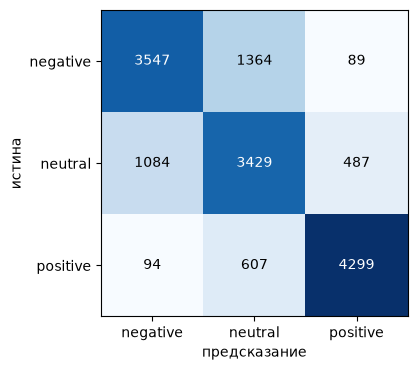

In [7]:
best = models["слова + биграммы + символы"]
test_pred = best.predict(test.text)
print(f"test accuracy: {accuracy_score(test.label_text, test_pred):.4f}")

cm = confusion_matrix(test.label_text, test_pred, labels=labels)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), labels)
ax.set_yticks(range(3), labels)
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, v, ha="center", va="center", color="w" if v > 2500 else "k")
ax.set(xlabel="предсказание", ylabel="истина")
plt.tight_layout()
plt.show()

Почти все ошибки — через `neutral`. Путаница negative ↔ positive редка. Посмотрим на ошибки,
в которых модель уверена сильнее всего.

In [8]:
proba = best.predict_proba(test.text)
confidence = proba.max(axis=1)
wrong = test.assign(pred=test_pred, conf=confidence)[test_pred != test.label_text]
wrong.sort_values("conf", ascending=False).head(10)[["label_text", "pred", "conf", "text"]].round(3)

,label_text,pred,conf,text
962,neutral,positive,1.000,"Очень хорошая футболочка, дочке пришлась в самый раз. Приятная к телу, интересный принт. Просто супер! Доставка 3 недели. Мы довольны з..."
4340,negative,positive,0.999,"Носочки супер, очень мягкие и приятные , без дефектов, быстрая доставка. Рекомендую продавца!"
12055,negative,positive,0.997,Прекрасное качество. Быстрая доставка. Очень довольна.
7238,neutral,positive,0.996,спасибо))
4289,neutral,positive,0.996,"Все хорошо, я довольна"
14641,negative,positive,0.995,"джинсы отличные. тянутся хорошо. заказала М на 44 размер, подошли идеально. Но можно было и С, так как растягиваются при носке"
7558,neutral,negative,0.992,товар так и не дошёл!! ни денег ни товара
11102,neutral,positive,0.991,"блузка очень красивая, на русск. 48 идеально подошла xxxl. рекомендую!"
13946,neutral,negative,0.989,Заказ не получила. деньги не вернули.
1127,neutral,negative,0.989,Был брак открыла спор продавец обманул деньги не вернул . не советую.


Многие «уверенные ошибки» — ошибки не модели, а разметки. RuReviews размечен автоматически по звёздам
(M02, урок 4). «Прекрасное качество. Быстрая доставка. Очень довольна.» размечено как `negative`,
«товар так и не дошёл!! ни денег ни товара» — как `neutral`. Модель читает текст, а метка — звёзды,
которые покупатель мог поставить по любой причине или по ошибке. На таких примерах **ни одна** модель не права,
и потолок accuracy на этих данных заметно ниже 100%.

Проверим ещё, насколько результат зависит от почти-дубликатов из train (M02, урок 4).

In [9]:
def normalize(s):
    # явный класс символов, а не \W: см. предупреждение ниже
    return s.str.lower().str.replace(r"[^0-9a-zа-яё]+", " ", regex=True).str.strip()


seen = set(normalize(train.text))
fresh = ~normalize(test.text).isin(seen)
print(f"отзывов теста, которых нет в train: {fresh.mean():.1%}")
print(f"accuracy на них: {accuracy_score(test.label_text[fresh], test_pred[fresh]):.4f}")

отзывов теста, которых нет в train: 97.2%
accuracy на них: 0.7514


Почти не отличается: пересечений мало, и оценка честная.

⚠️ **Ловушка pandas 3.** В этом окружении установлен pyarrow (его требует библиотека `datasets`),
и pandas хранит строки в формате Arrow. Регулярные выражения тогда выполняет движок RE2, в котором
`\w` и `\W` знают только латиницу. `str.replace(r"\W+", " ")` превратит «Платье супер!» в пробел,
и все русские отзывы «совпадут» друг с другом. В M02 pyarrow не было, и тот же код работал.
Для русского текста пишите класс символов явно: `[^0-9a-zа-яё]`.

## ✅ Итоги

- TF-IDF + логистическая регрессия — baseline на три четверти правильных ответов за секунды.
- n-граммы частично возвращают порядок слов, символьные n-граммы справляются с морфологией и опечатками.
- Веса линейной модели интерпретируемы: видно, на что она опирается.
- Уверенные ошибки стоит читать глазами: часто это шум в метках, и он задаёт потолок качества.

✍️ **Упражнение:** `exercises/ex01_tfidf.py` — TF-IDF с нуля (со сверкой по scikit-learn).